# MoE Backbone Tests on BDD100K

Testing the new MoE architectures (WP-M0) on actual BDD100K data streams. We will visualize how router probabilities differ between different driving conditions.

In [40]:
import sys
from pathlib import Path

# Add repository root to path
repo_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "cafl4ds/configs").is_dir()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Open this notebook from within the cafl4ds repository.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [41]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
from omegaconf import OmegaConf
from hydra.utils import instantiate
from cafl4ds.models.moe import MoETinyViTEncoder

# BDD100K configuration
bdd_root = Path(r"D:\AI Proj\bdd100k_images_100k")
bdd_split = "train"
images_dir = bdd_root / "images" / "100k" / bdd_split
labels_file = bdd_root / "labels" / f"bdd100k_labels_images_{bdd_split}.json"

source_cfg = OmegaConf.create({
    "_target_": "cafl4ds.data.attributes.BDD100KSource",
    "bdd_root": str(bdd_root),
    "split": bdd_split,
    "images_dir": str(images_dir),
    "labels_file": str(labels_file),
    "img_size": 32, # small size for quick testing
    "max_images": None, # set to None to use all images
    "min_canary_count": 32,
})

stream_cfg = OmegaConf.create({
    "_target_": "cafl4ds.data.regime.RegimeStream",
    "batch_size": 32,
    "support_per_canary": 8,
    "query_per_canary": 8,
    "era_query_per_cell": 0,
    "max_train_per_regime": 128,
    "canary_seed": 0,
})


# --- Change this variable to test different Regimes ---
# e.g. 'daytime', 'night', 'dawn/dusk'
target_regime_name = 'daytime'

In [42]:
try:
    source = instantiate(source_cfg)
    stream = instantiate(stream_cfg, source=source, seed=13)
    logger.info(f"Loaded {len(stream)} batches.")
except Exception as e:
    logger.warning(f"Could not load BDD100K data (please verify path): {e}")
    stream = None

2026-10-05 11:12:47.392 | INFO     | cafl4ds.data.attributes:_drop_rare_scenes:455 - BDD100KSource: dropped rare scenes below min_canary_count=32: ['gas stations', 'tunnel']
2026-10-05 11:17:27.974 | INFO     | cafl4ds.data.attributes:_decode:332 - BDD100KSource: loaded 61438 images (train) at 32px over 18 regimes, 4 scenes
2026-10-05 11:17:28.275 | INFO     | __main__:<module>:4 - Loaded 63 batches.


## Visualizing MoE Routing on BDD100K

Here we test the MoE Backbone routing logic on the BDD100K stream. We initialize our `MoETinyViTEncoder` and feed it a batch of images to check which experts process which tokens.

In [50]:
# Initialize the MoE Encoder
encoder = MoETinyViTEncoder(
    img_size=32, patch_size=8, in_chans=3, embed_dim=96, 
    depth=4, num_heads=3, mlp_ratio=2.0, num_experts=4, 
    top_k=1, moe_blocks=(2, 3), routing_level='token', 
    balancing_mode='batch'
)

if stream is not None and len(stream) > 0:
    
    target_era = 0
    if hasattr(stream, 'regime_names') and hasattr(stream, '_regime_order'):
        try:
            # stream.regime_names is a dict[int, str]
            reg_id = next(k for k, v in stream.regime_names.items() if v == target_regime_name)
            target_era = stream._regime_order.index(reg_id)
        except (ValueError, StopIteration):
            logger.warning(f"Regime '{target_regime_name}' not found. Using first batch.")
            
    batch = next((b for b in stream if b.era == target_era), None)
    if batch is None:
        batch = next(iter(stream))
    imgs = batch.images
    logger.info(f"Processing batch for '{target_regime_name}' with {imgs.shape[0]} images.")
else:
    # Fallback to dummy data if dataset is not found
    logger.info("Using dummy data for testing.")
    imgs = torch.randn(8, 3, 32, 32)

# Forward pass to get routing probabilities
embeds = encoder.embed(imgs)
probs = encoder.routing(imgs)

print(f"Auxiliary balancing loss: {encoder.aux_loss:.4f}")

2026-10-05 11:23:13.806 | WARNING  | __main__:<module>:18 - Regime 'daytime' not found. Using first batch.
2026-10-05 11:23:13.808 | INFO     | __main__:<module>:24 - Processing batch for 'daytime' with 32 images.


Auxiliary balancing loss: 10.1756


### Routing Probabilities Visualization

We visualize the routing probabilities for each MoE block. A heatmap illustrates how tokens (y-axis) are distributed among the 4 experts (x-axis).

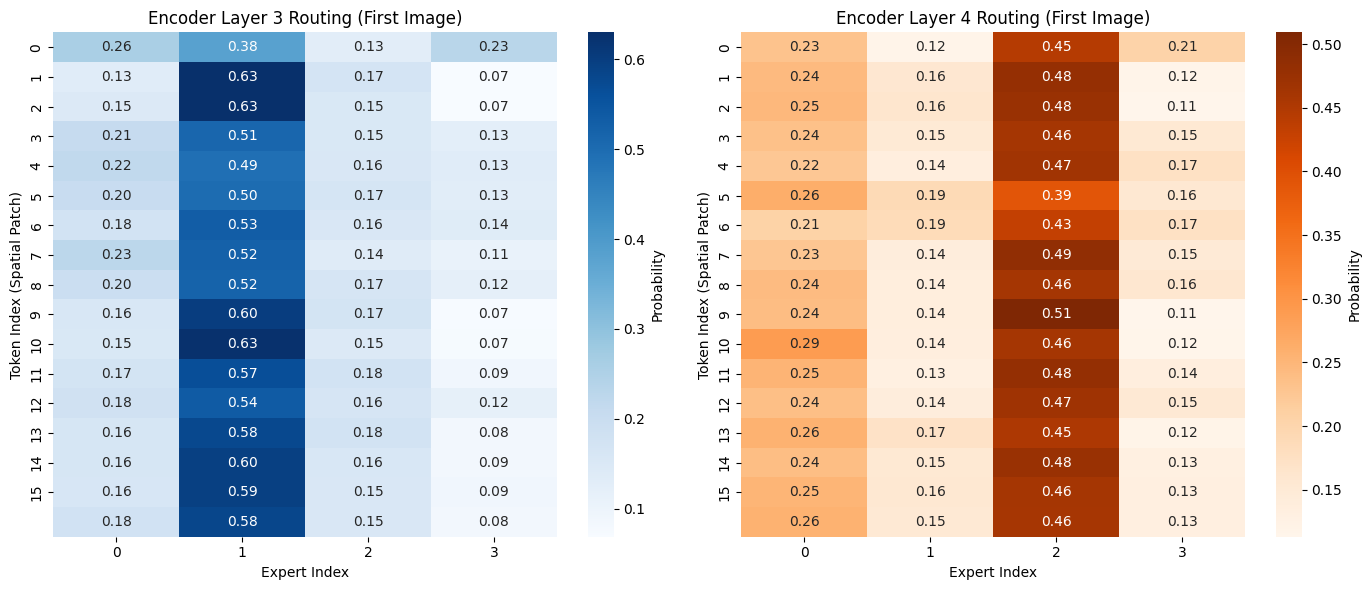

In [54]:
probs_block2 = probs[0].detach().numpy()  # [B, T, E]
probs_block3 = probs[1].detach().numpy()  # [B, T, E]

sample_idx = 0 # Visualize the first image in the batch

# The token index corresponds to a 4x4 grid of patches (32x32 image / 8x8 patch size)
yticklabels = [f"{i}" for i in range(16)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(probs_block2[sample_idx], cmap='Blues', ax=axes[0], cbar_kws={'label': 'Probability'}, annot=True, fmt=".2f", yticklabels=yticklabels)
axes[0].set_title(f'Encoder Layer 3 Routing (First Image)')
axes[0].set_xlabel('Expert Index')
axes[0].set_ylabel('Token Index (Spatial Patch)')

sns.heatmap(probs_block3[sample_idx], cmap='Oranges', ax=axes[1], cbar_kws={'label': 'Probability'}, annot=True, fmt=".2f", yticklabels=yticklabels)
axes[1].set_title(f'Encoder Layer 4 Routing (First Image)')
axes[1].set_xlabel('Expert Index')
axes[1].set_ylabel('Token Index (Spatial Patch)')

plt.tight_layout()
plt.show()

### Mean Expert Usage

Let's look at the overall expert usage across the entire batch.

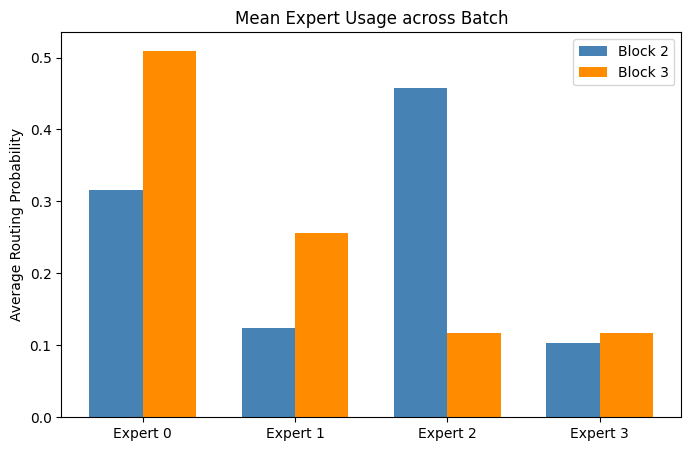

In [45]:
# Compute average expert load across the batch and all tokens
mean_usage_block2 = probs_block2.mean(axis=(0, 1))
mean_usage_block3 = probs_block3.mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(8, 5))
width = 0.35
x = range(4)

ax.bar([i - width/2 for i in x], mean_usage_block2, width, label='Block 2', color='steelblue')
ax.bar([i + width/2 for i in x], mean_usage_block3, width, label='Block 3', color='darkorange')

ax.set_ylabel('Average Routing Probability')
ax.set_title('Mean Expert Usage across Batch')
ax.set_xticks(x)
ax.set_xticklabels([f'Expert {i}' for i in x])
ax.legend()

plt.show()